## Best Optimization Hidden Size

In [1]:
from Pipeline.Algorithm.ArtificialBeeColonyElmCV import ArtificialBeeColonyElmCV
from Pipeline.Global.GallstoneDataSet import GallstoneDataSet
from Pipeline.Global.GlobalSetting import GlobalSetting
from Pipeline.Global.Plotting import Plotting
from Pipeline.Optimization.ABC_Testing import abc_testing

In [2]:
gallstone_dataset = GallstoneDataSet()
gallstone_dataset.fetch_data_path_1()

features_size = gallstone_dataset.x_train_scaled.shape[1]
x_train = gallstone_dataset.x_train
x_test  = gallstone_dataset.x_test
y_train = gallstone_dataset.y_train
y_test  = gallstone_dataset.y_test

In [3]:
best_optimization_config = GlobalSetting.get_config_by_type("Grid_Optimization")
best_optimization_hidden_size = best_optimization_config["Hidden_Nodes"] if best_optimization_config else None

In [4]:
abc_elm_optimize_hidden  = ArtificialBeeColonyElmCV(
        features_size       = features_size                     ,
        hidden_size         = best_optimization_hidden_size     ,
        activation_function = GlobalSetting.sigmoid             ,
        fitness_function    = GlobalSetting.evaluation_function ,
        solution_size       = GlobalSetting.solution_size       ,
        trial_limit         = GlobalSetting.trial_limit         ,
        max_iteration       = GlobalSetting.max_iteration
    )

In [5]:
results_df , convergence_df , scout_df = abc_testing(abc_elm_optimize_hidden,x_train, y_train, x_test, y_test)
results_df.describe()

Seed 21 start

Iteration 1 end : 0.0763s | Scout Triggers: 0
Iteration 2 end : 0.0711s | Scout Triggers: 0
Iteration 3 end : 0.0833s | Scout Triggers: 0
Iteration 4 end : 0.0890s | Scout Triggers: 0
Iteration 5 end : 0.0743s | Scout Triggers: 0
Iteration 6 end : 0.0880s | Scout Triggers: 0
Iteration 7 end : 0.0690s | Scout Triggers: 2
Iteration 8 end : 0.0615s | Scout Triggers: 0
Iteration 9 end : 0.0603s | Scout Triggers: 0
Iteration 10 end : 0.0838s | Scout Triggers: 2
Iteration 11 end : 0.0863s | Scout Triggers: 1
Iteration 12 end : 0.0777s | Scout Triggers: 0
Iteration 13 end : 0.0704s | Scout Triggers: 1
Iteration 14 end : 0.0646s | Scout Triggers: 1
Iteration 15 end : 0.0612s | Scout Triggers: 0
Iteration 16 end : 0.0838s | Scout Triggers: 1
Iteration 17 end : 0.0732s | Scout Triggers: 2
Iteration 18 end : 0.0655s | Scout Triggers: 0
Iteration 19 end : 0.0604s | Scout Triggers: 0
Iteration 20 end : 0.0853s | Scout Triggers: 1

Seed 21 end : 1.548617s


Seed 22 start

Iteration 1 

,Accuracy,Precision,Recall,NPV,Specificity,F1-Score,F2-Score,Bal Accuracy,MCC,ABC_Seed
count,5.000000,5.000000,5.00000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000
mean,0.762500,0.780143,0.73125,0.750026,0.793750,0.753447,0.739661,0.762500,0.527567,23.000000
std,0.048664,0.044429,0.08149,0.059652,0.047393,0.056849,0.071330,0.048664,0.096026,1.581139
min,0.703125,0.709677,0.62500,0.684211,0.718750,0.689655,0.649351,0.703125,0.406449,21.000000
25%,0.718750,0.769231,0.68750,0.696970,0.781250,0.698413,0.691824,0.718750,0.445399,22.000000
50%,0.781250,0.787879,0.71875,0.750000,0.812500,0.766667,0.737179,0.781250,0.566947,23.000000
75%,0.796875,0.812500,0.81250,0.806452,0.812500,0.800000,0.807453,0.796875,0.594040,24.000000
max,0.812500,0.821429,0.81250,0.812500,0.843750,0.812500,0.812500,0.812500,0.625000,25.000000


[I/O Trace] Figure exported successfully: ../../Storage/Figure\ABC_Telemetry_Grid_Optimization_Hidden_Nodes_F1-Score.png


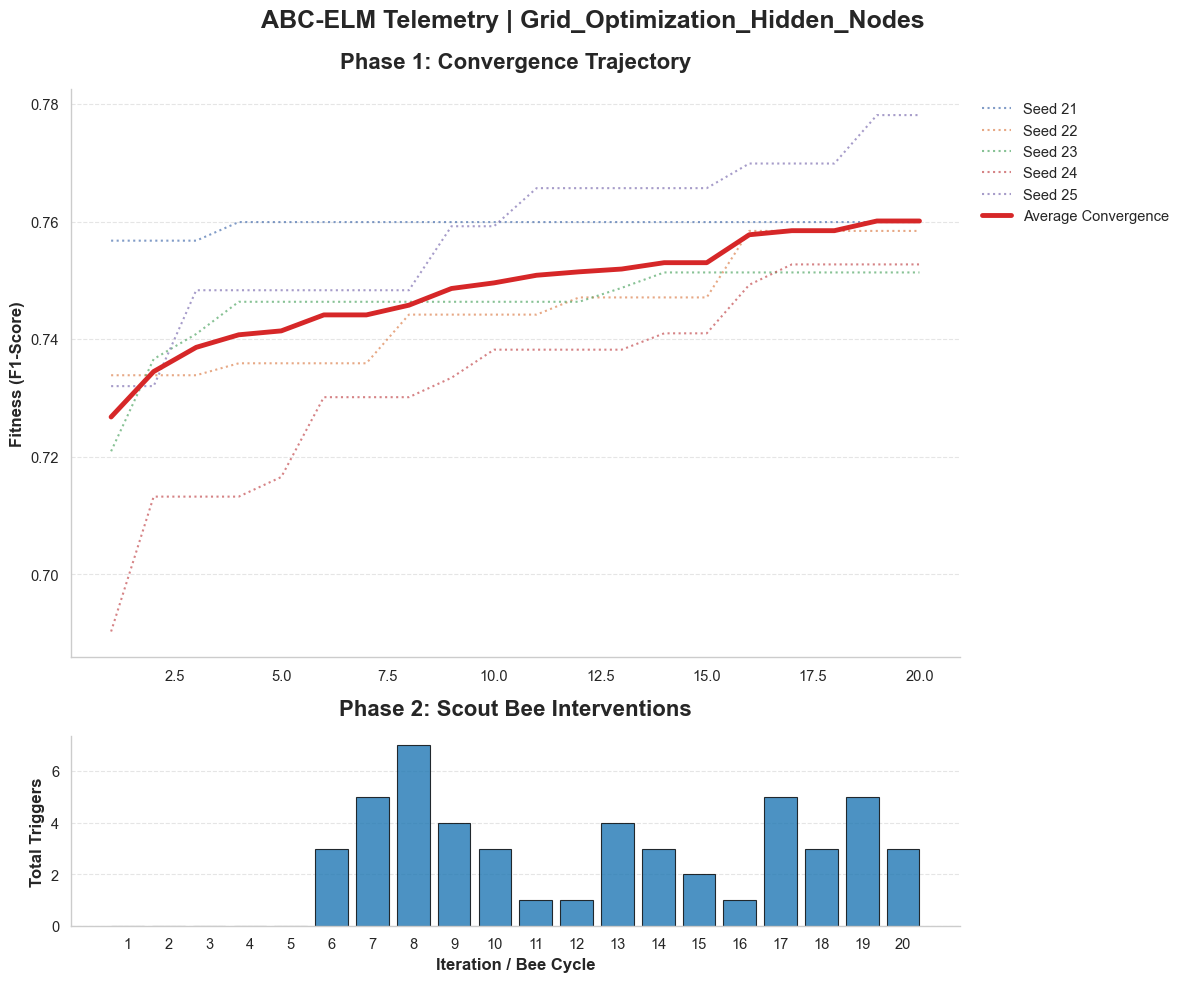

In [6]:
Plotting.plot_abc_dashboard(convergence_df,scout_df,"Grid_Optimization_Hidden_Nodes",is_final_record=True)